# Insurance Charges Prediction

## 1. Introduction

Text text text

Dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance

## 2. Importing and Preprocessing

In [102]:
import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




In [5]:
### Download latest version
path = kagglehub.dataset_download('mirichoi0218/insurance')

#print('Path to dataset files:', path)

### Lead file onto dataframe
df = pd.read_csv(os.path.join(path, 'insurance.csv'))

In [6]:
### Initialize a random_state for reproducibility
random_state = 42

In [7]:
### Print first rows of dataframe to verify dataframe was loaded properly
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
### Print basic information 
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
### Print number of duplicate entries
print(df.duplicated().sum())

### Print duplicate entries
df[df.duplicated()]

1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
### Print basic statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Exploratory Data Analysis 

In [11]:


### Transform "sex" into a numerical binary variable
if df['sex'].isin(['male', 'female']).any():
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})

### Transform "smoker" into a numerical binary variable
if df['smoker'].isin(['yes', 'no']).any():
    df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})




In [12]:
# Percentage of women
pct_women = df['sex'].mean() * 100

# Percentage of smokers 
pct_smokers = df['smoker'].mean() * 100

print(f"Women: {pct_women:.2f}%")
print(f"Smokers: {pct_smokers:.2f}%")

Women: 49.48%
Smokers: 20.48%


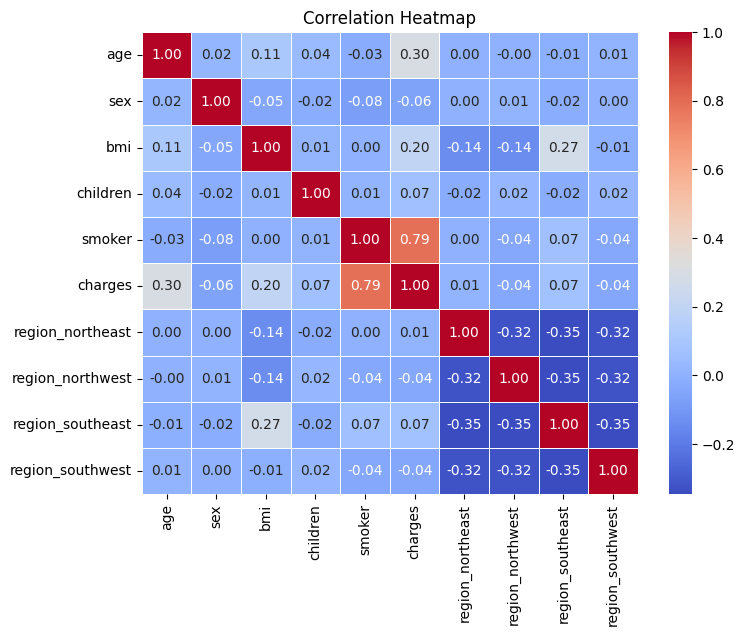

In [13]:
### Correlation matrix of all variables

df_corr_copy = df.copy()

### Get dummy variables for region
if 'region' in df.columns:
    df_corr_copy = pd.get_dummies(df_corr_copy, columns=['region'])

matrix = df_corr_copy.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

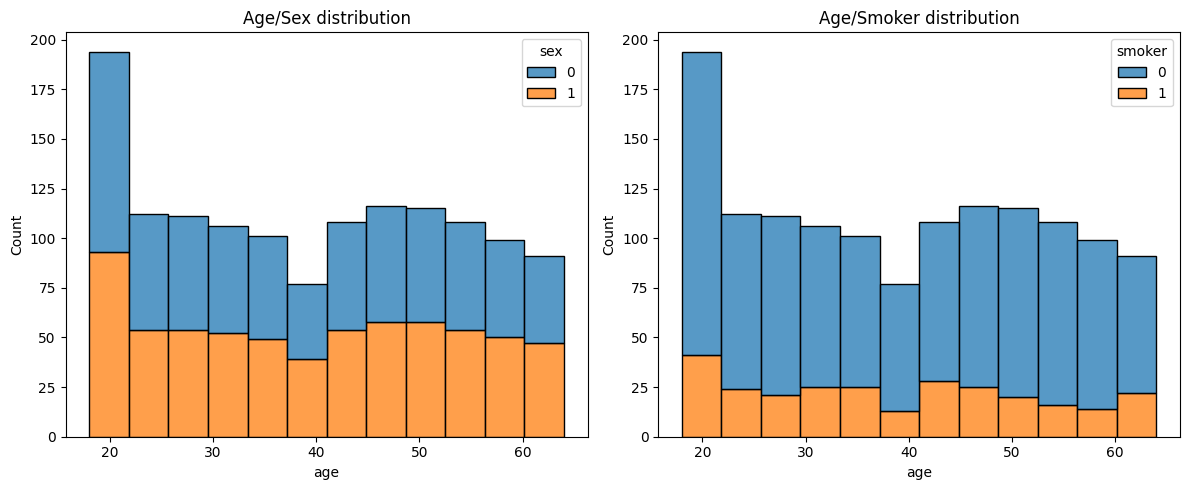

In [14]:
### Plot age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='age', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('Age/Sex distribution')

sns.histplot(data=df, x='age', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('Age/Smoker distribution')

plt.tight_layout()
plt.show()



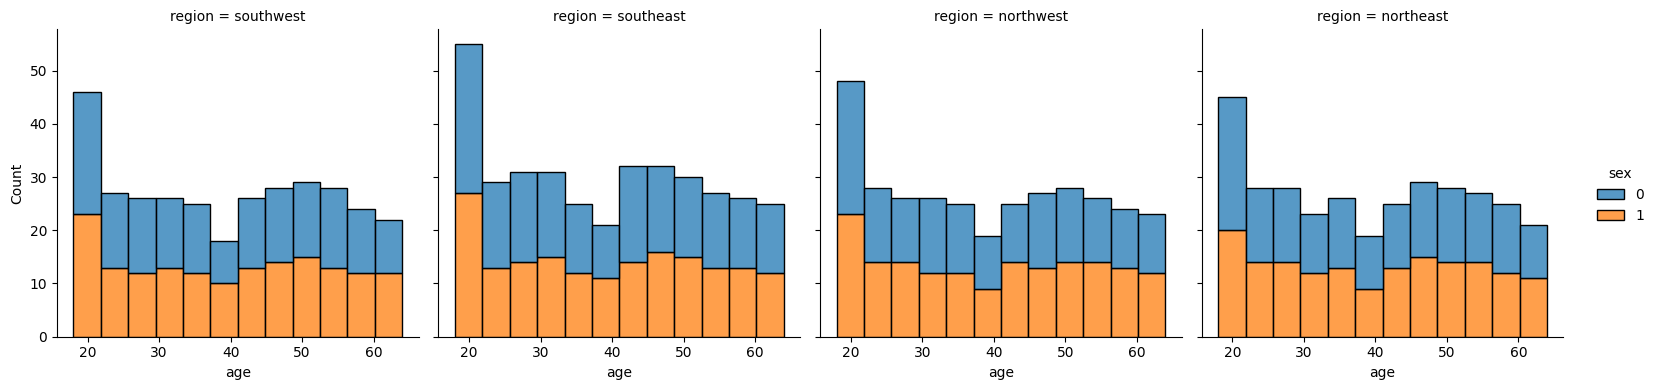

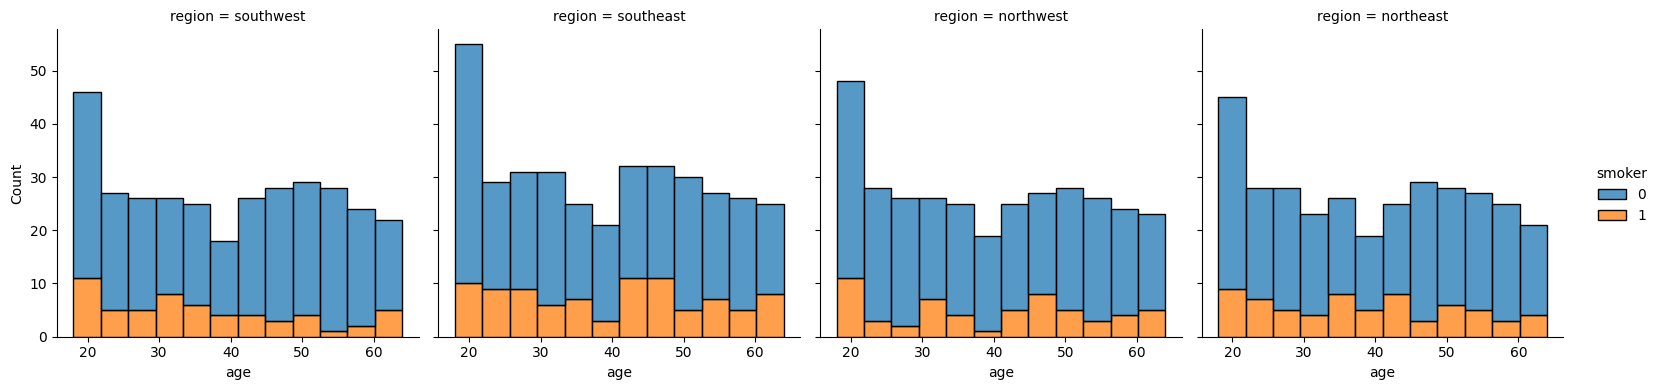

In [15]:
sns.displot(data=df, x='age', hue='sex', col='region', multiple='stack', height=4, aspect=1)

sns.displot(data=df, x='age', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

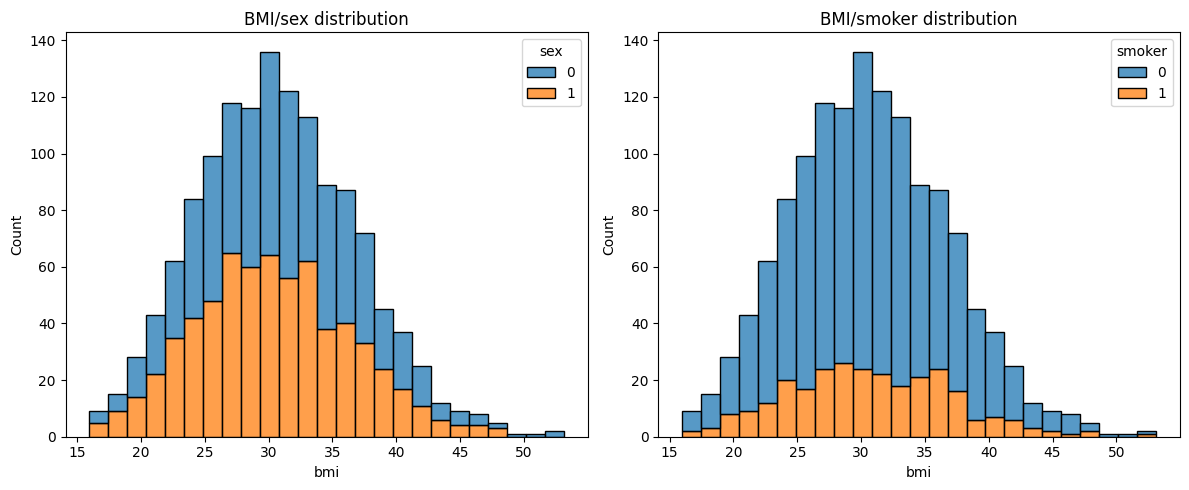

In [16]:
### Plot charges distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='bmi', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('BMI/sex distribution')

sns.histplot(data=df, x='bmi', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('BMI/smoker distribution')

plt.tight_layout()
plt.show()

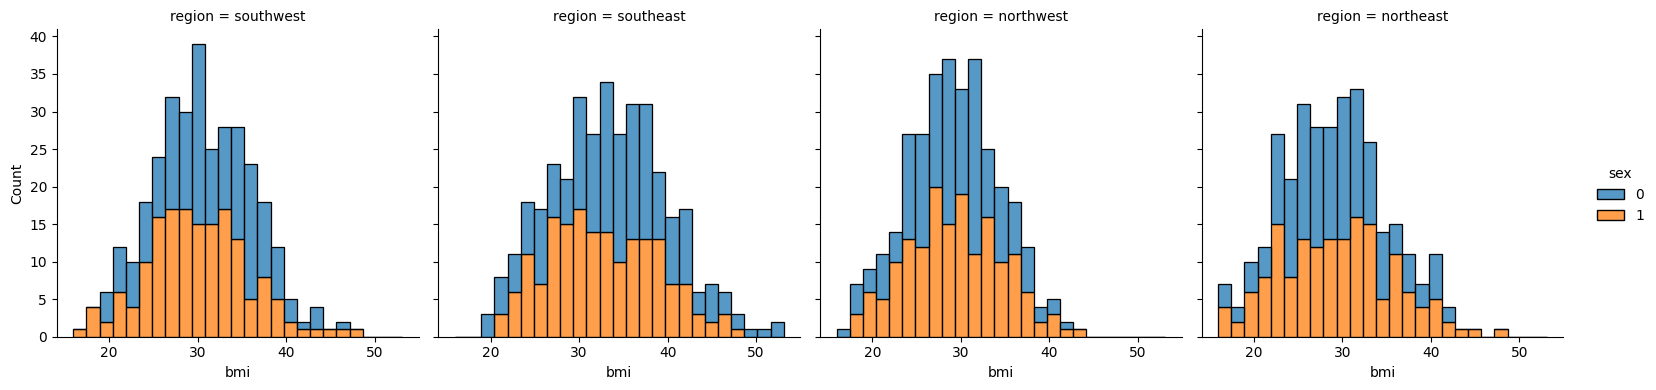

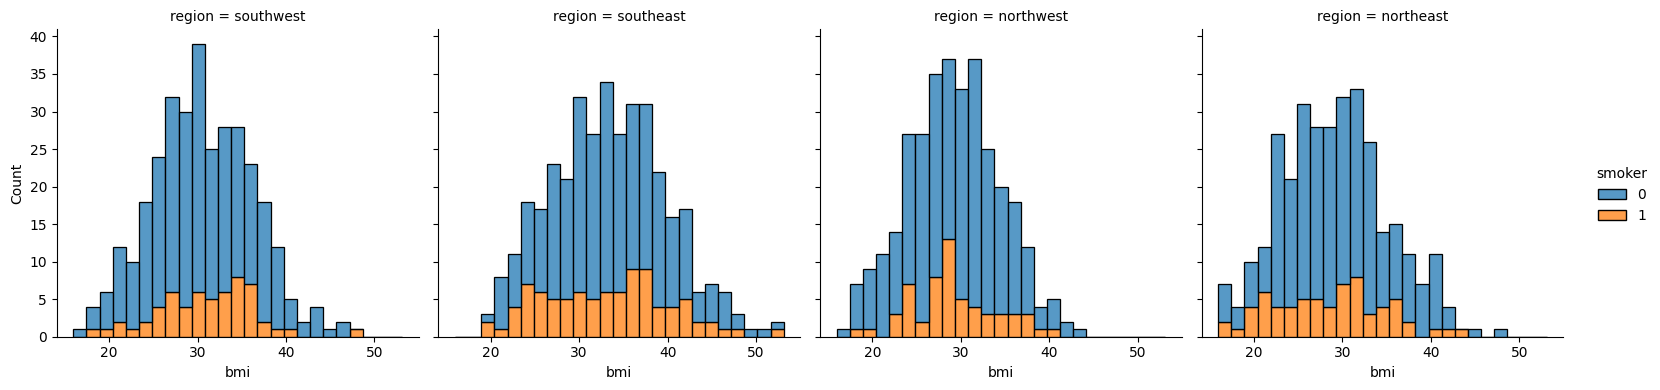

In [17]:
sns.displot(data=df, x='bmi', hue='sex', col='region', multiple='stack', height=4, aspect=1)

sns.displot(data=df, x='bmi', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

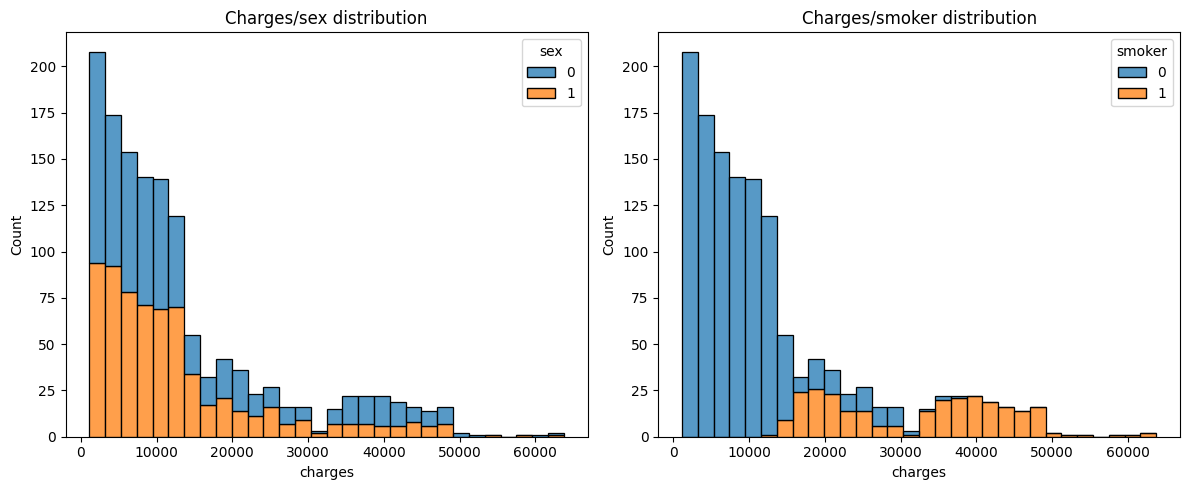

In [18]:
### Plot charges distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='charges', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('Charges/sex distribution')

sns.histplot(data=df, x='charges', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('Charges/smoker distribution')

plt.tight_layout()
plt.show()

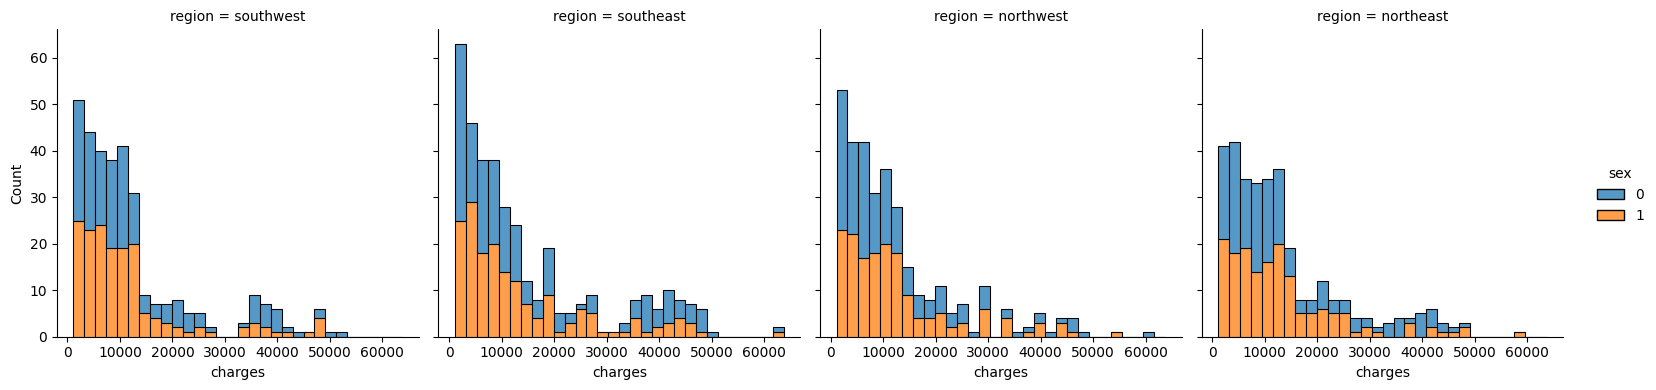

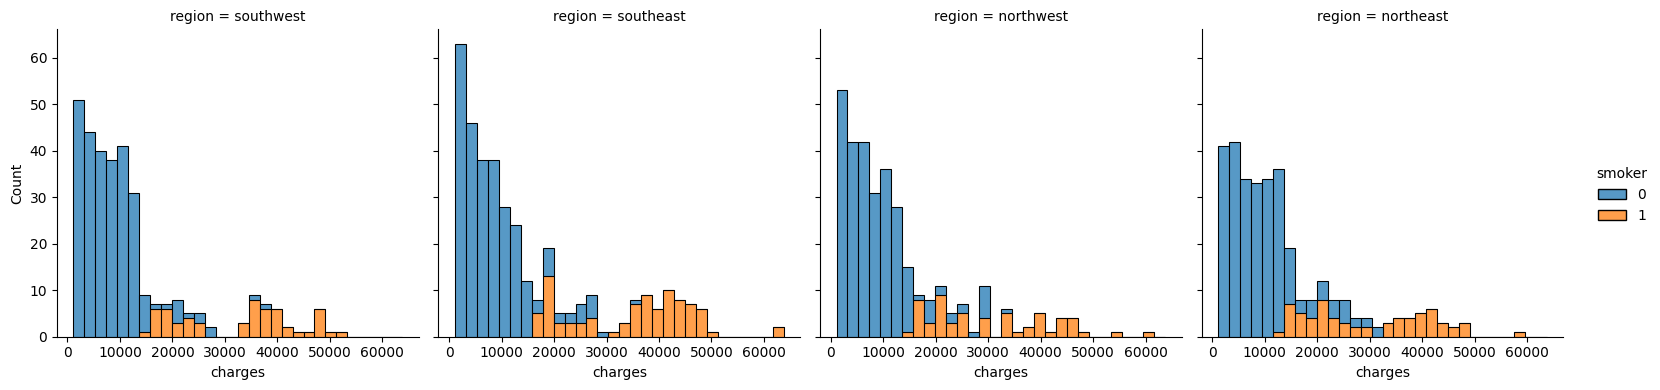

In [19]:
sns.displot(data=df, x='charges', hue='sex', col='region', multiple='stack', height=4, aspect=1)

sns.displot(data=df, x='charges', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

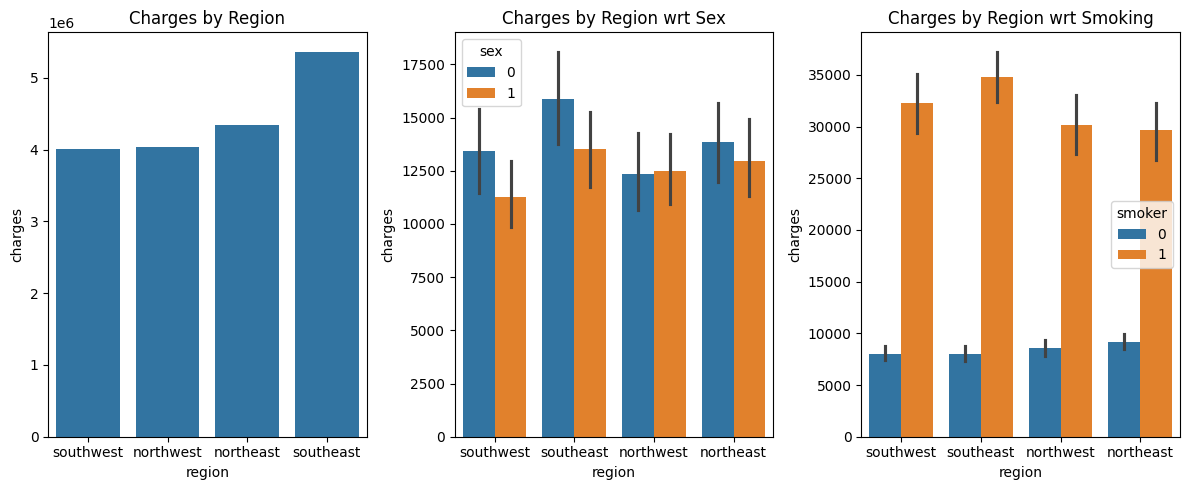

In [20]:
### Plot charges by region 
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

charges = df['charges'].groupby(df.region).sum().sort_values(ascending = True)
sns.barplot(data = charges, ax = axes[0])
axes[0].set_title('Charges by Region')

sns.barplot(data=df, x='region', y ='charges', hue = 'sex', ax=axes[1])
axes[1].set_title('Charges by Region wrt Sex')

sns.barplot(data=df, x='region', y ='charges', hue = 'smoker', ax=axes[2])
axes[2].set_title('Charges by Region wrt Smoking')

plt.tight_layout()
plt.show()



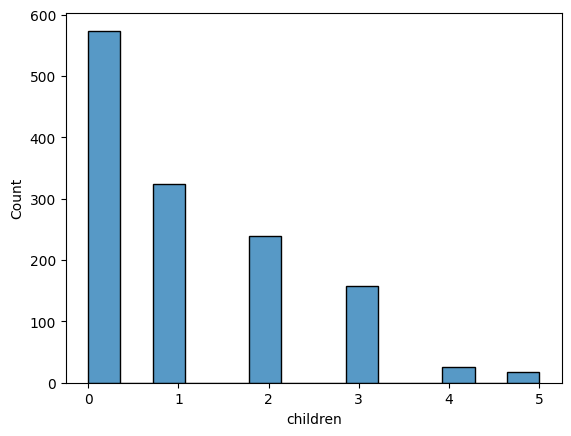

In [21]:
sns.histplot(data=df, x='children')
plt.show()


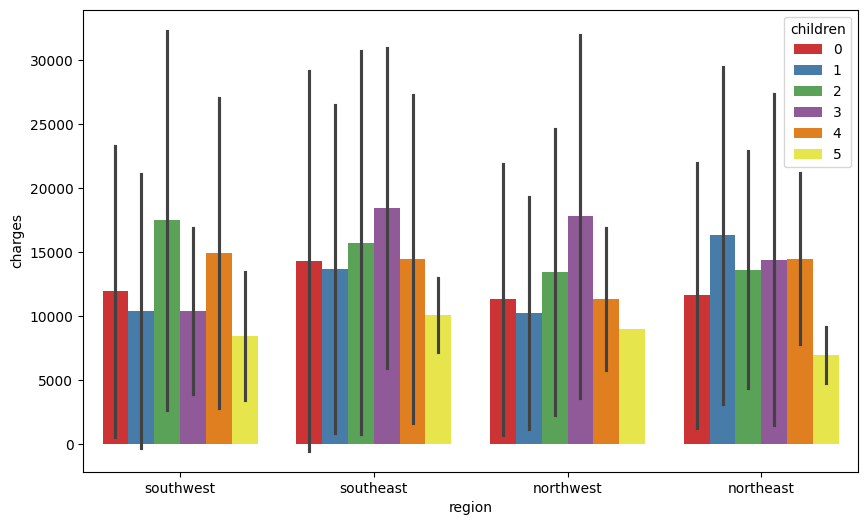

In [22]:
### Plot charges by region wrt number  of children
fig,ax = plt.subplots(1, 1, figsize=(10, 6)) 
sns.barplot(data=df, x='region', y ='charges', hue = 'children', palette='Set1', errorbar="sd")
plt.show()


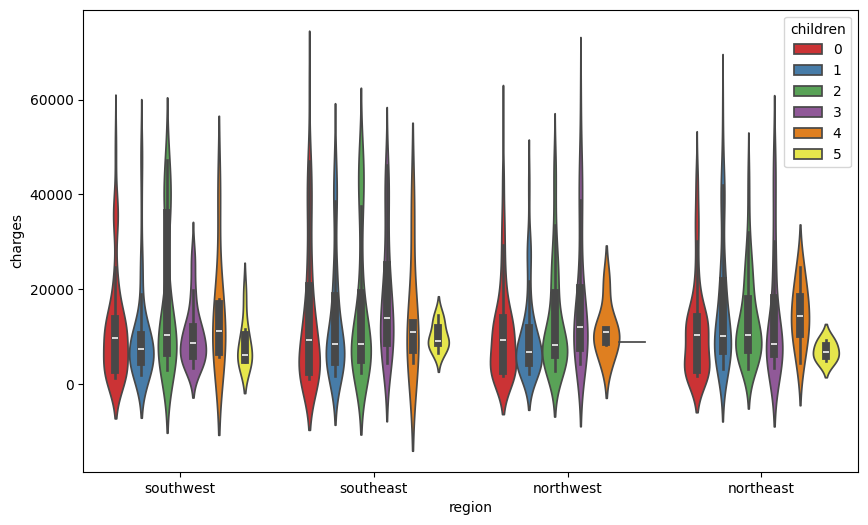

In [23]:
fig,ax = plt.subplots(1, 1, figsize=(10, 6)) 
sns.violinplot(data=df, x='region', y='charges', hue='children', palette='Set1', inner='box')
plt.show()



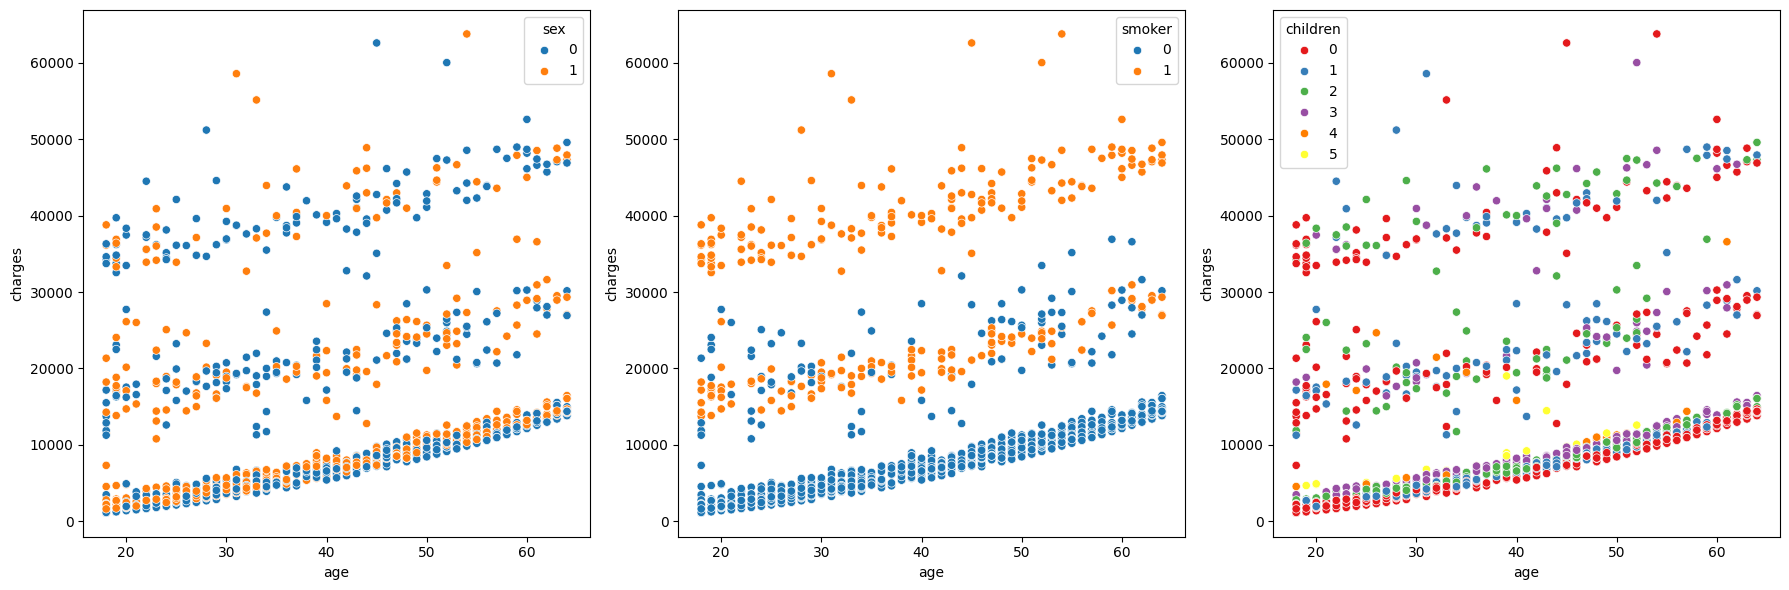

In [24]:
###Scatter plots 
fig,axes = plt.subplots(1, 3, figsize=(18,6)) 

sns.scatterplot(df, x = 'age', y='charges',hue = 'sex', ax = axes[0])

sns.scatterplot(df, x = 'age', y='charges',hue = 'smoker', ax = axes[1])

sns.scatterplot(df, x = 'age', y='charges',hue = 'children', palette='Set1',ax = axes[2])


plt.tight_layout()
plt.show()


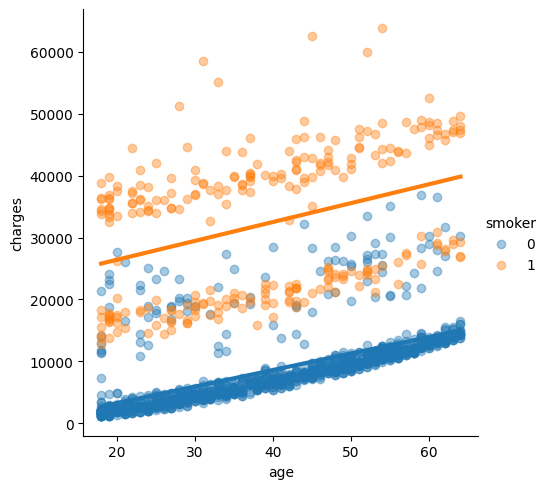

In [25]:
sns.lmplot(data=df, x='age', y='charges', hue='smoker', ci=None, scatter_kws={'alpha': 0.4}, line_kws={'linewidth': 3})

plt.show()

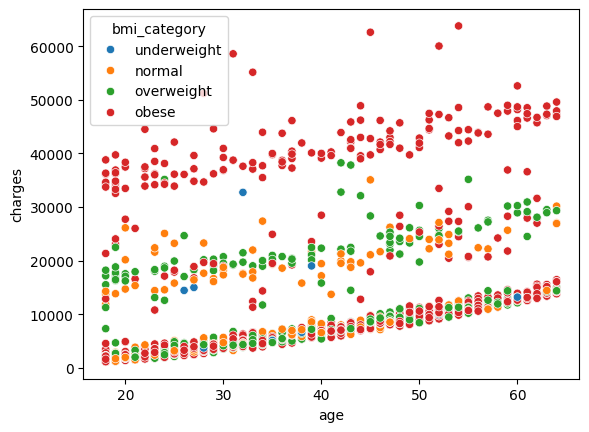

In [26]:
df_bmi_copy = df.copy()

bins = [0, 18.5, 25, 30, float("inf")]
labels = ["underweight", "normal", "overweight", "obese"]

df_bmi_copy["bmi_category"] = pd.cut(df_bmi_copy["bmi"], bins=bins, labels=labels)

sns.scatterplot(data=df_bmi_copy, x='age', y='charges', hue='bmi_category', hue_order=labels)

plt.show()

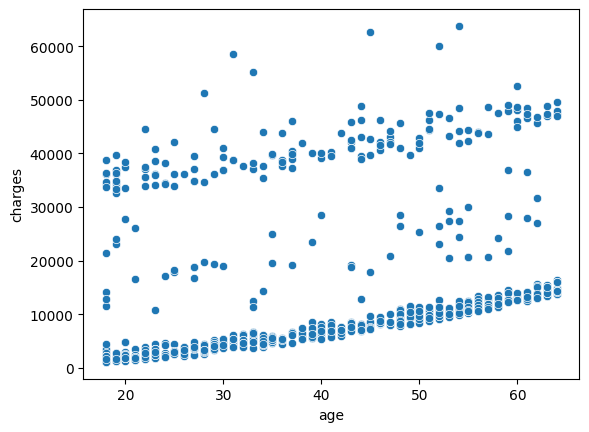

In [27]:
df_bmi_copy = df.copy()

bins = [0, 18.5, 25, 30, float("inf")]
labels = ["underweight", "normal", "overweight", "obese"]

df_bmi_copy["bmi_category"] = pd.cut(df_bmi_copy["bmi"], bins=bins, labels=labels)

obese_df = df_bmi_copy[df_bmi_copy["bmi_category"] == "obese"]

sns.scatterplot(data=obese_df, x='age', y='charges')

plt.show()

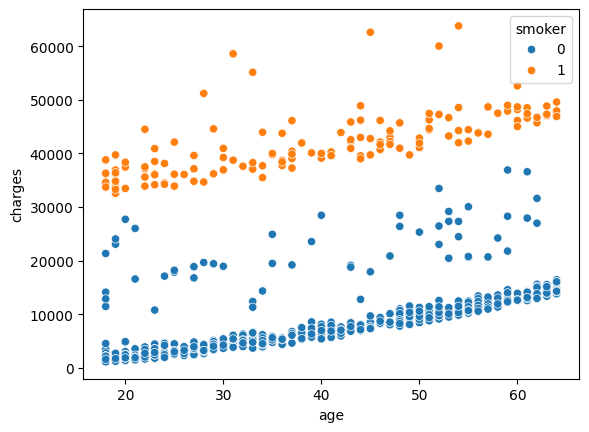

In [28]:
sns.scatterplot(data=obese_df, x='age', y='charges', hue='smoker')

plt.show()

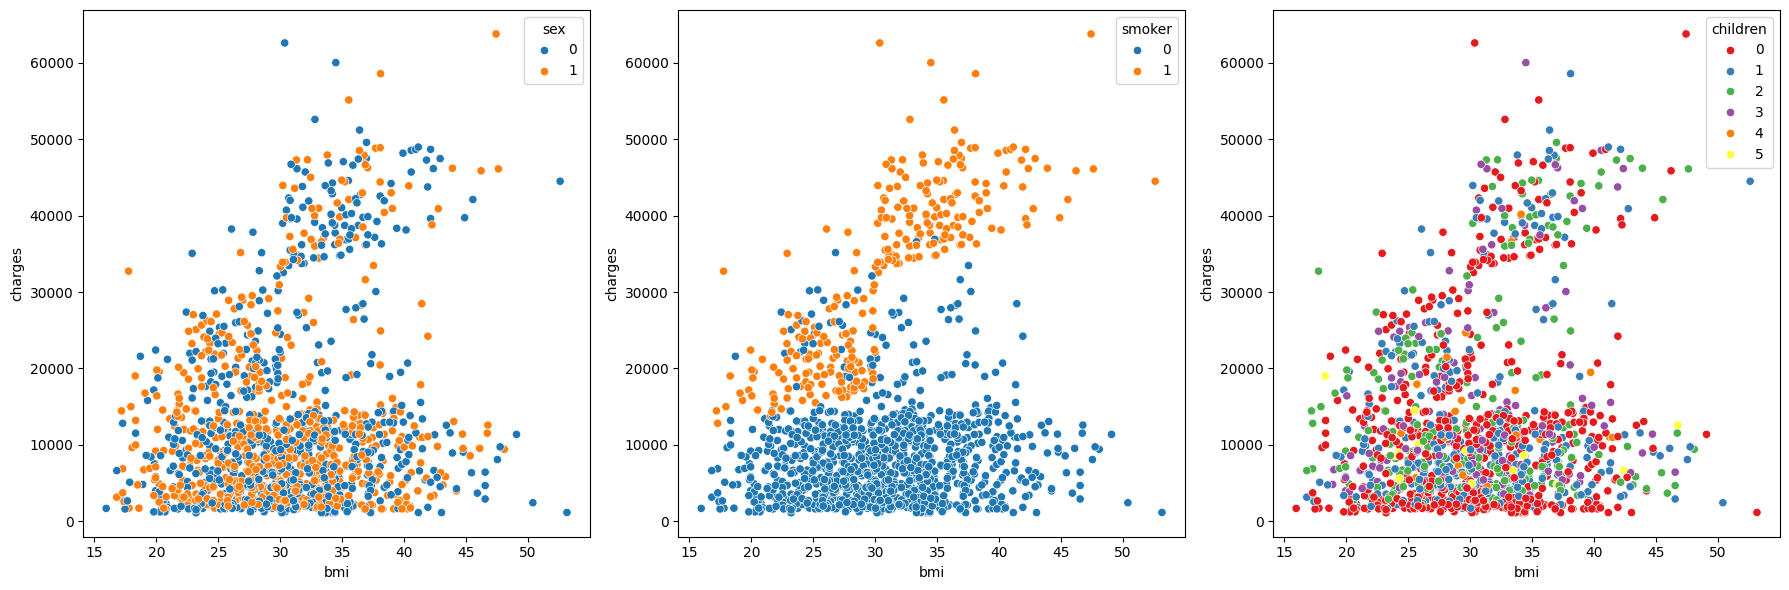

In [29]:
### Scatter plots 
fig,axes = plt.subplots(1, 3, figsize=(18,6)) 

sns.scatterplot(df, x = 'bmi', y='charges',hue = 'sex', ax = axes[0])

sns.scatterplot(df, x = 'bmi', y='charges',hue = 'smoker', ax = axes[1])

sns.scatterplot(df, x = 'bmi', y='charges',hue = 'children', palette='Set1', ax = axes[2])

plt.tight_layout()
plt.show()

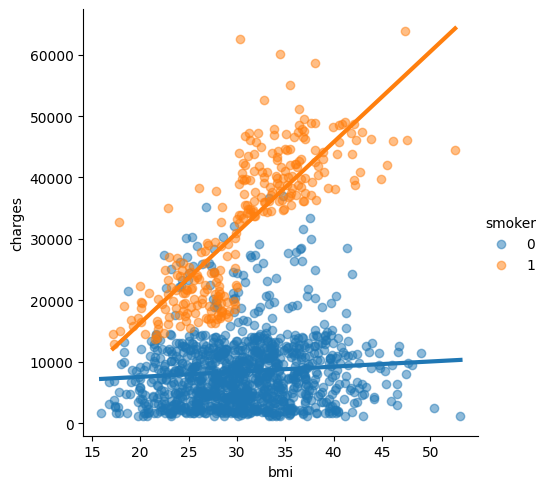

In [30]:
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', ci=None, scatter_kws={'alpha': 0.5}, line_kws={'linewidth': 3})

plt.show()

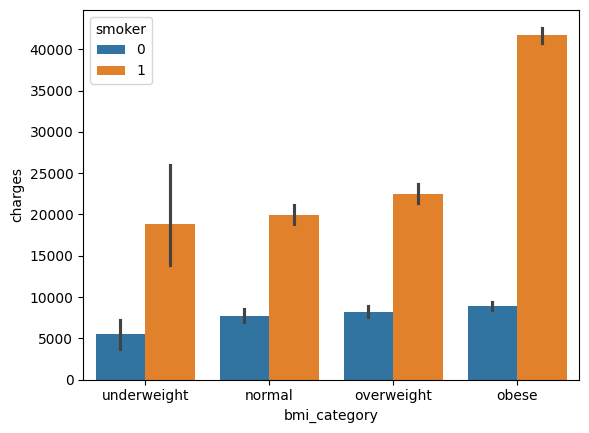

In [31]:
sns.barplot(data = df_bmi_copy, x='bmi_category', y='charges', hue = 'smoker')
plt.show()

## 4. Feature Engineering and Feature Selection

In [32]:
### Separating data into predictors and target variables
X = df.drop(columns = 'charges')
y = df['charges']


In [33]:
### Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [34]:
### Encoding for region variable
if 'region' in X_train.columns:
    X_train = pd.get_dummies(X_train, columns=["region"], drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=["region"], drop_first=True, dtype=int)

### Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_test = X_test[X_train.columns]

### Make copies of raw features before feature engineering
X_train_raw = X_train.copy()
X_test_raw = X_test.copy() 

### Adding constant for regression
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [35]:
### Function to compare proportions of variables
def compare_proportions(X_train, X_test):
    summary = {}

    for col in X_train.columns:
        train_dist = X_train[col].value_counts(normalize=True, dropna=False)
        test_dist  = X_test[col].value_counts(normalize=True, dropna=False)
        diff = np.abs(train_dist - test_dist)

        summary[col] = pd.DataFrame({
            'train': train_dist,
            'test': test_dist,
            'difference' : diff
        }).fillna(0)

    return summary

In [36]:
### Check smokers 
proportions = compare_proportions(X_train, X_test)

print(proportions['smoker'])

           train      test  difference
smoker                                
0       0.794393  0.798507    0.004115
1       0.205607  0.201493    0.004115


In [37]:
### Fitting initial model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Tue, 19 May 2026   Prob (F-statistic):          1.32e-305
Time:                        16:23:53   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.195e+04   1121.021  

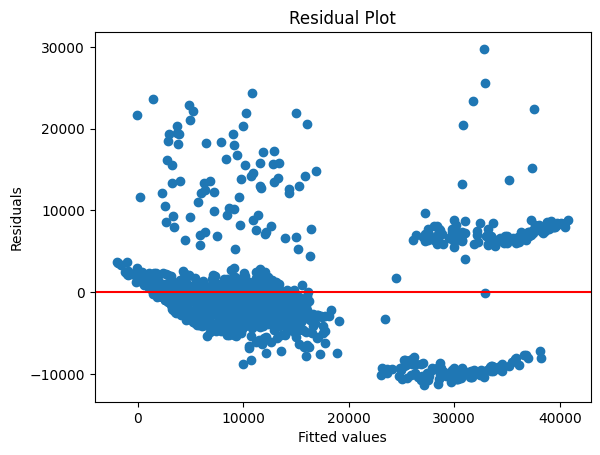

In [38]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [39]:
### Verify logarithm of bmi and charges can be taken
assert (X_train['bmi'] <= 0).sum() == 0
assert (y_train <= 0).sum() == 0

### Logarithmic transform of bmi
X_train['bmi'] = np.log(X_train['bmi'])
X_test['bmi'] = np.log(X_test['bmi'])

### Logarithmic transform of charges
y_train = np.log(y_train)
y_test = np.log(y_test)

In [40]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     415.4
Date:                Tue, 19 May 2026   Prob (F-statistic):          1.44e-320
Time:                        16:23:54   Log-Likelihood:                -659.67
No. Observations:                1070   AIC:                             1337.
Df Residuals:                    1061   BIC:                             1382.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.9373      0.240  

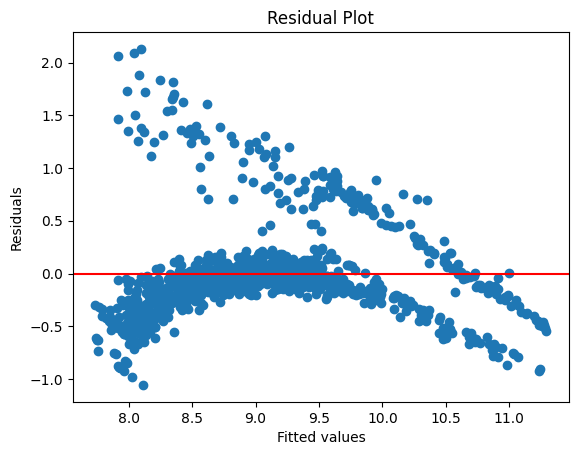

In [41]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [42]:

X_train['smoker x bmi'] = X_train['smoker'] * X_train['bmi']
X_test['smoker x bmi'] = X_test['smoker'] * X_test['bmi']

In [43]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     403.5
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:23:54   Log-Likelihood:                -622.95
No. Observations:                1070   AIC:                             1266.
Df Residuals:                    1060   BIC:                             1316.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9633      0.260  

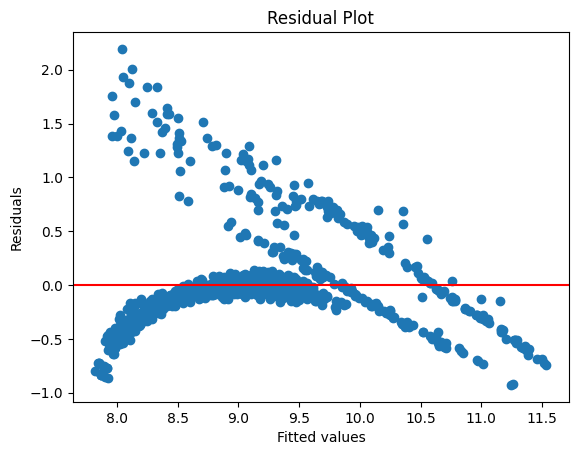

In [44]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

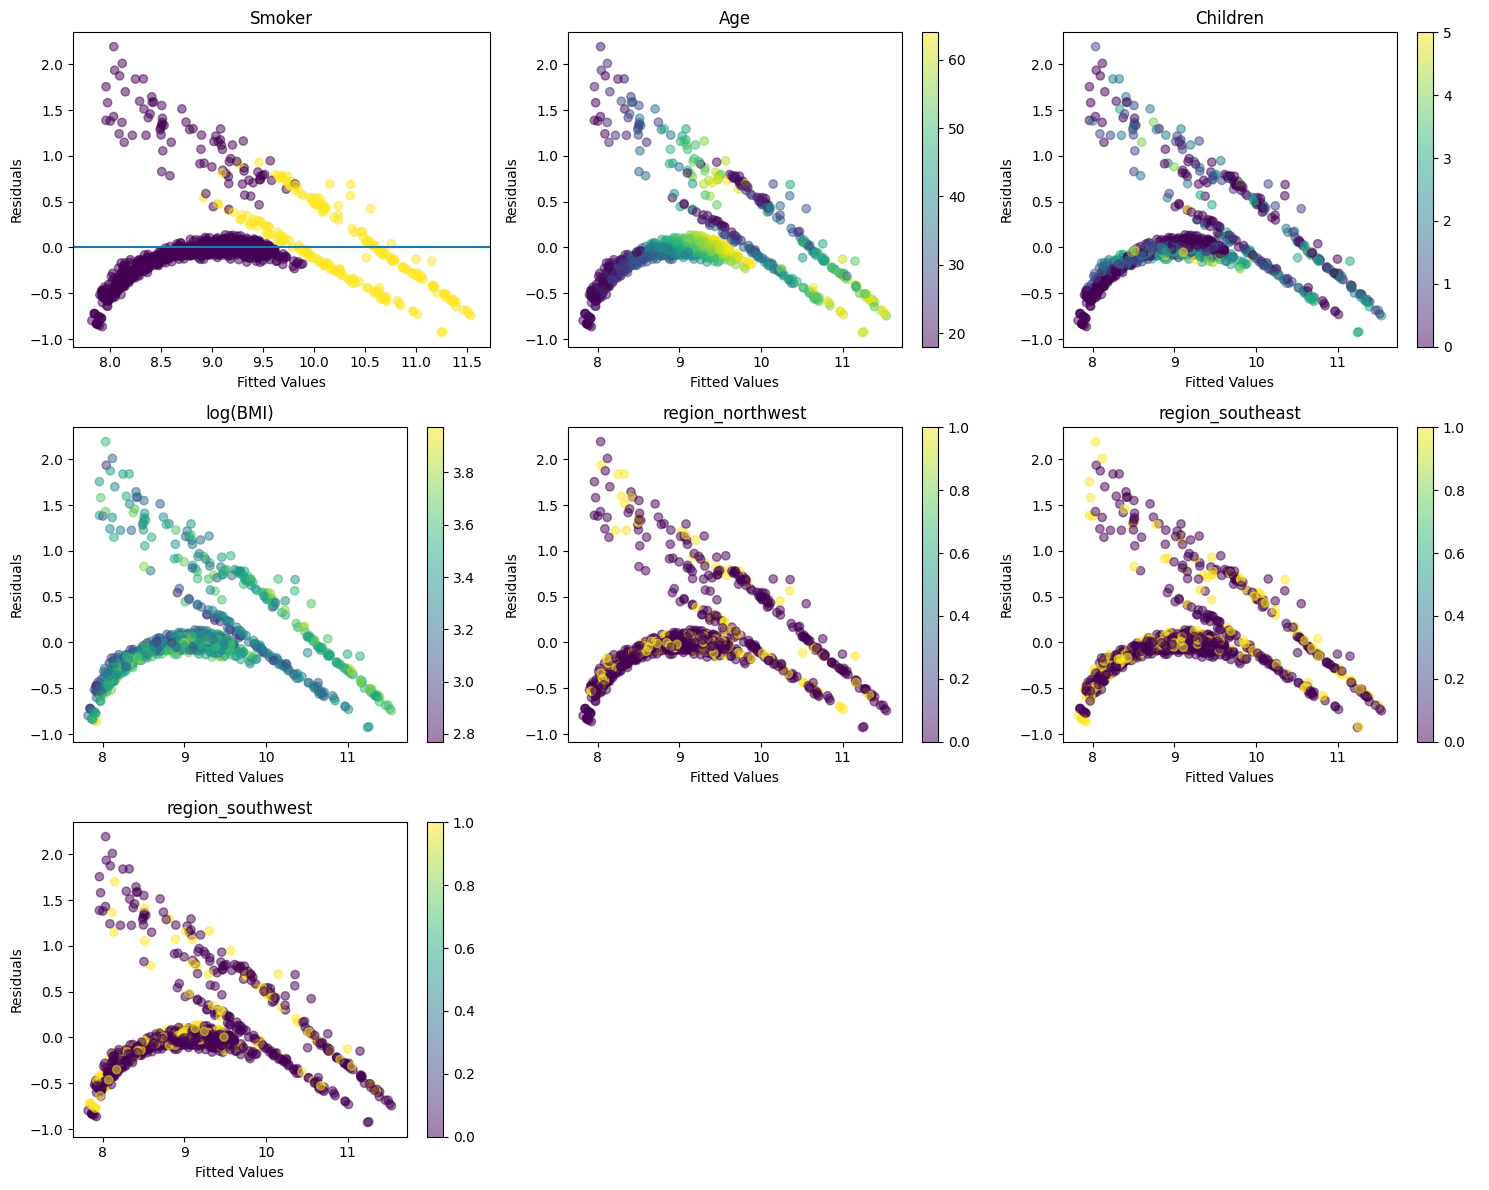

In [45]:
### Residual Plots with color dependence on feature
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# 1. Smoker
sc0 = axes[0].scatter(model.fittedvalues, model.resid, c=X_train['smoker'], alpha=0.5)
axes[0].axhline(0)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title("Smoker")

# 2. Age
sc1 = axes[1].scatter(model.fittedvalues, model.resid, c=X_train['age'], alpha=0.5)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title("Age")
fig.colorbar(sc1, ax=axes[1])

# 3. Children
sc2 = axes[2].scatter(model.fittedvalues, model.resid, c=X_train['children'], alpha=0.5)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title("Children")
fig.colorbar(sc2, ax=axes[2])

# 4. BMI
sc3 = axes[3].scatter(model.fittedvalues, model.resid, c=X_train['bmi'], alpha=0.5)
axes[3].set_xlabel('Fitted Values')
axes[3].set_ylabel('Residuals')
axes[3].set_title("log(BMI)")
fig.colorbar(sc3, ax=axes[3])

# 5–7. Regions
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']
for i, col in enumerate(region_cols, start=4):    
    sc = axes[i].scatter(model.fittedvalues, model.resid, c=X_train[col], alpha=0.5)
    axes[i].set_xlabel('Fitted Values')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(col)    
    fig.colorbar(sc, ax=axes[i])

# Hide unused subplots
for j in range(7, 9):    
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [46]:
### Define new feature smoker x age
X_train['smoker x age'] = X_train['smoker'] * X_train['age']
X_test['smoker x age'] = X_test['smoker'] * X_test['age']

In [47]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     474.4
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:23:58   Log-Likelihood:                -508.63
No. Observations:                1070   AIC:                             1039.
Df Residuals:                    1059   BIC:                             1094.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9452      0.234  

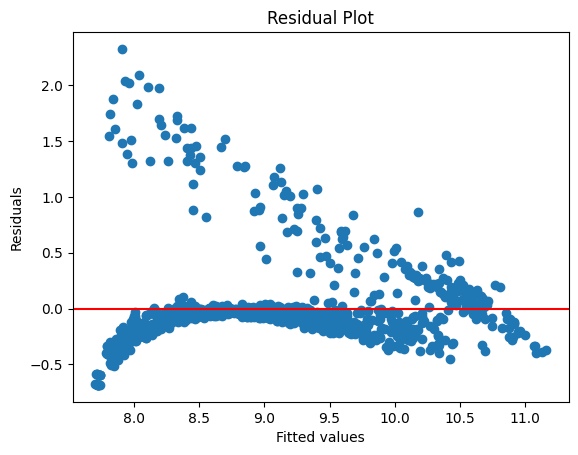

In [48]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [49]:
### Define new feature age^2
X_train['age^2'] = X_train['age']**2
X_test['age^2'] = X_test['age']**2

In [50]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     436.8
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:23:58   Log-Likelihood:                -502.69
No. Observations:                1070   AIC:                             1029.
Df Residuals:                    1058   BIC:                             1089.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.5648      0.258  

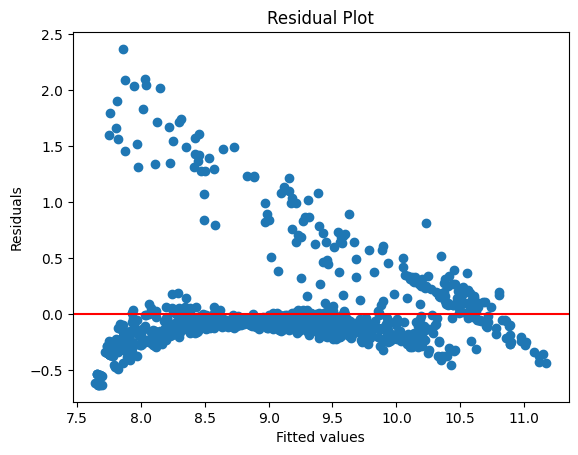

In [51]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [52]:
### Define new feature obese smoker (= 1 if obese smoker, = 0 if not)
X_train['obese_smoker'] = (X_train['bmi'] > np.log(30)) * X_train['smoker']
X_test['obese_smoker'] = (X_test['bmi'] > np.log(30)) * X_test['smoker']

In [53]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     415.6
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:23:59   Log-Likelihood:                -485.88
No. Observations:                1070   AIC:                             997.8
Df Residuals:                    1057   BIC:                             1062.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.5451      0.254  

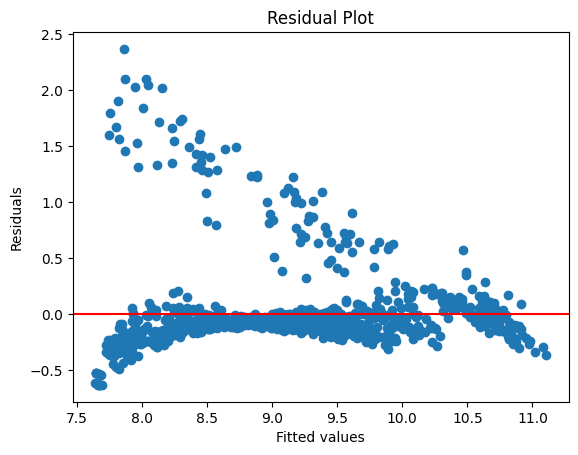

In [54]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We check whether the target data would benefit from a Box-Cox transform instead of a logarithmic transform 

In [55]:
### Transform data back into original scale
y_train_original = np.exp(y_train)

### Find optimal Box-Cox transformation parameter
y_train_bc, lambda_opt = stats.boxcox(y_train_original)
print(f"\nOptimal lambda: {lambda_opt:.4f}")

### Apply transform
y_train_bc = (y_train_original ** lambda_opt - 1) / lambda_opt


Optimal lambda: 0.0593


In [56]:
### Fitting the model
model_bc = sm.OLS(y_train_bc, X_train).fit()
print(model_bc.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     422.1
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:23:59   Log-Likelihood:                -1055.8
No. Observations:                1070   AIC:                             2138.
Df Residuals:                    1057   BIC:                             2202.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.9302      0.432  

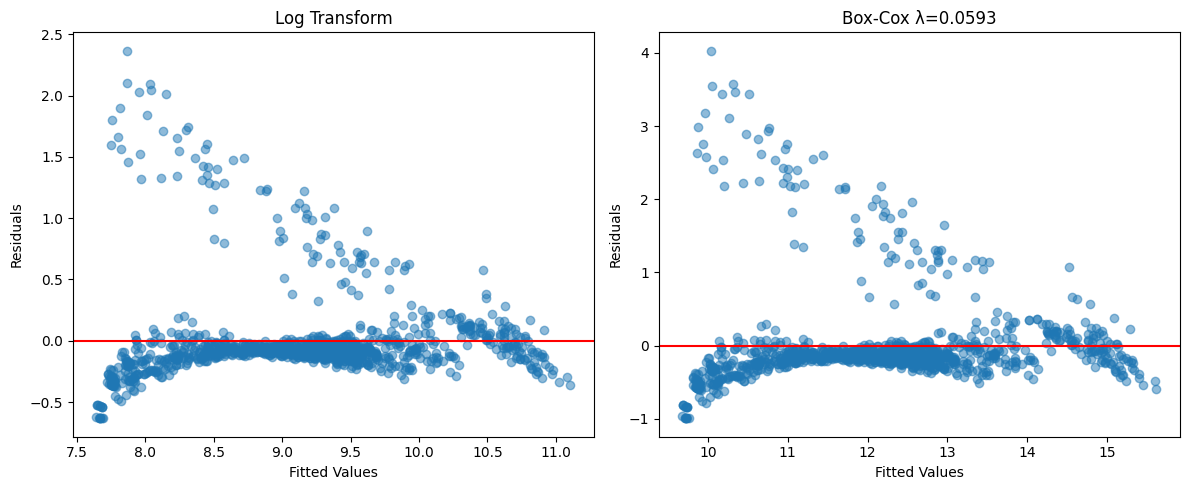

In [57]:
# Compare residuals (they will be nearly identical)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(model.fittedvalues, model.resid, alpha=0.5)
ax1.axhline(0, color='red')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Log Transform')

ax2.scatter(model_bc.fittedvalues, model_bc.resid, alpha=0.5)
ax2.axhline(0, color='red')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f"Box-Cox λ={lambda_opt:.4f}")

plt.tight_layout()
plt.show()

The model does not seem to benefit from a Box-Cox transform significantly, and loses the appeal of log-transform's simplicity, so we abandon this approach.

In [58]:
### Define new feature bmi^2
X_train['bmi^2'] = X_train['bmi']**2
X_test['bmi^2'] = X_test['bmi']**2

In [59]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     385.0
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:00   Log-Likelihood:                -483.91
No. Observations:                1070   AIC:                             995.8
Df Residuals:                    1056   BIC:                             1065.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5649      2.533  

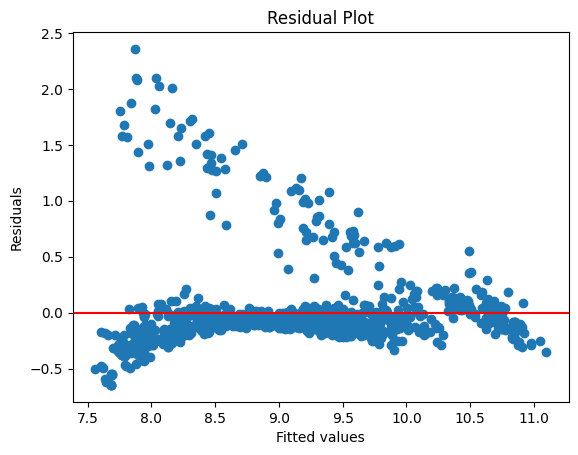

In [60]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We additionally apply Heteroscedasticity-Robust Standard Errors to try to correct the heteroscedasticity that is visible for low Fitted values.

In [61]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     683.2
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:00   Log-Likelihood:                -483.91
No. Observations:                1070   AIC:                             995.8
Df Residuals:                    1056   BIC:                             1065.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5649      2.268  

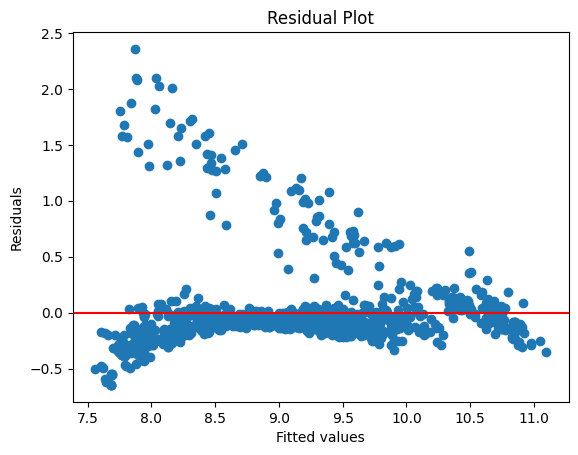

In [62]:
### Residual plot
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We verify if there is strong multicolinearity

In [63]:
vif = pd.DataFrame()
vif['features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif.sort_values('VIF', ascending=False))

            features           VIF
0              const  46851.954382
9       smoker x bmi    688.234742
3                bmi    668.476149
13             bmi^2    668.114202
5             smoker    622.656595
1                age     47.883868
11             age^2     47.449258
10      smoker x age      8.735819
12      obese_smoker      5.510852
7   region_southeast      1.618931
8   region_southwest      1.523513
6   region_northwest      1.509225
4           children      1.103244
2                sex      1.012752


We will remove a couple of features that influence multicolinearity strongly and that appeared to not have improved to model a lot. 
We choose bmi^2 ang age^2 that are already taken into account for by other features.

In [64]:
X_train = X_train.drop(columns = ['bmi^2','age^2'])
X_test = X_test.drop(columns = ['bmi^2','age^2'])

print(X_train.columns)

Index(['const', 'age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker x bmi', 'smoker x age',
       'obese_smoker'],
      dtype='object')


In [65]:
### Fitting the final model
model = sm.OLS(y_train, X_train).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     766.1
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:01   Log-Likelihood:                -492.67
No. Observations:                1070   AIC:                             1009.
Df Residuals:                    1058   BIC:                             1069.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9456      0.249  

## 5. Modeling and Evaluation 

EXPLAIN TACTIC ( ML MODELS AND SKLEARN)

In [66]:
X_train = X_train.drop(columns='const')
X_test = X_test.drop(columns='const')

### 5.1. Evaluation Functions

EXPLAIN FUNCTION

In [67]:
def cross_val_rmse(model, X, y, n_splits=5, log = True):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmse_scores = []

    for train_idx, val_idx in kf.split(X):

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model_clone = clone(model)

        model_clone.fit(X_tr, y_tr)

        y_pred = model_clone.predict(X_val)

        ### If log transformed data needs back transformation
        if log == True:
            y_pred = np.exp(y_pred)
            y_true = np.exp(y_val)
        
        else:
            y_true = y_val

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

EXPLAIN FUNCTION

In [79]:
def evaluate_model(pipe, X_train, X_test, y_train, y_test, log = True, name = ''):

    ### List to store scores    
    scores = []

    ### If no name provided manually, use model class name   
    if name == '':
        name =pipe.named_steps['model'].__class__.__name__

    ### Calculate CV RMSE
    CV_RMSE = cross_val_rmse(pipe, X_train, y_train, log = log, n_splits = 5)
    scores.append(CV_RMSE)

    ### If log transformed data needs back transformation
    if log: 
        ### Predictions in log-space
        y_train_pred_log = pipe.predict(X_train)
        y_test_pred_log = pipe.predict(X_test)

        ### Back-transform predictions
        y_train_pred = np.exp(y_train_pred_log)
        y_test_pred = np.exp(y_test_pred_log)

        ### Back-transform true targets
        y_train_true = np.exp(y_train)
        y_test_true = np.exp(y_test)

    ### Otherwise no need for that
    else:
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        y_train_true = y_train
        y_test_true = y_test

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    scores.append(train_rmse)
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    scores.append(test_rmse)

    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    scores.append(train_mae)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    scores.append(test_mae)

    train_r2 = r2_score(y_train_true, y_train_pred)
    scores.append(train_r2)
    test_r2 = r2_score(y_test_true, y_test_pred)
    scores.append(test_r2)

    print(f"\n{name}")
    print("-" * 40)

    print("Train:")
    print(f"CV RMSE: {CV_RMSE:.4f}")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"MAE:  {train_mae:.2f}")
    print(f"R²:   {train_r2:.4f}")

    print("\nTest:")
    print(f"RMSE: {test_rmse:.2f}")
    print(f"MAE:  {test_mae:.2f}")
    print(f"R²:   {test_r2:.4f}")

    return scores

EXPLAIN FUNCTION

In [81]:
def graph_residuals(pipe, X_test, y_test, name = ''):

    ### If no name provided manually, use model class name   
    if name == '':
        name = pipe.named_steps['model'].__class__.__name__

    
    ### Predict on test set
    y_test_pred = pipe.predict(X_test)

    ### True values of test set
    y_test_true = y_test

    ### Define residuals
    residuals_test = y_test_true - y_test_pred

    ### Initialize subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ### Residual plot on test set
    axes[0].scatter(y_test_pred, residuals_test, alpha=0.5)
    axes[0].axhline(0)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residual Plot (Test set)')

    ### Heteroscedasticity check on test set
    axes[1].scatter(y_test_pred, np.abs(residuals_test), alpha=0.5)
    axes[1].set_xlabel("Predicted values")
    axes[1].set_ylabel("|Residuals|")
    axes[1].set_title("Heteroscedasticity Check")

    ### Actual vs Predicted on test set
    axes[2].scatter(y_test_true, y_test_pred, alpha=0.5)
    axes[2].plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()])
    axes[2].set_xlabel("Actual")
    axes[2].set_ylabel("Predicted")
    axes[2].set_title("Actual vs Predicted")

    plt.show()

### 5.2. OLS

Few words

In [84]:
### Initialize pipeline
pipe_ols = Pipeline([
    ('model', LinearRegression())
])

### Fit model on training data
pipe_ols.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



LinearRegression
----------------------------------------
Train:
CV RMSE: 4962.6731
RMSE: 4949.64
MAE:  2460.56
R²:   0.8303

Test:
RMSE: 4631.22
MAE:  2256.68
R²:   0.8618


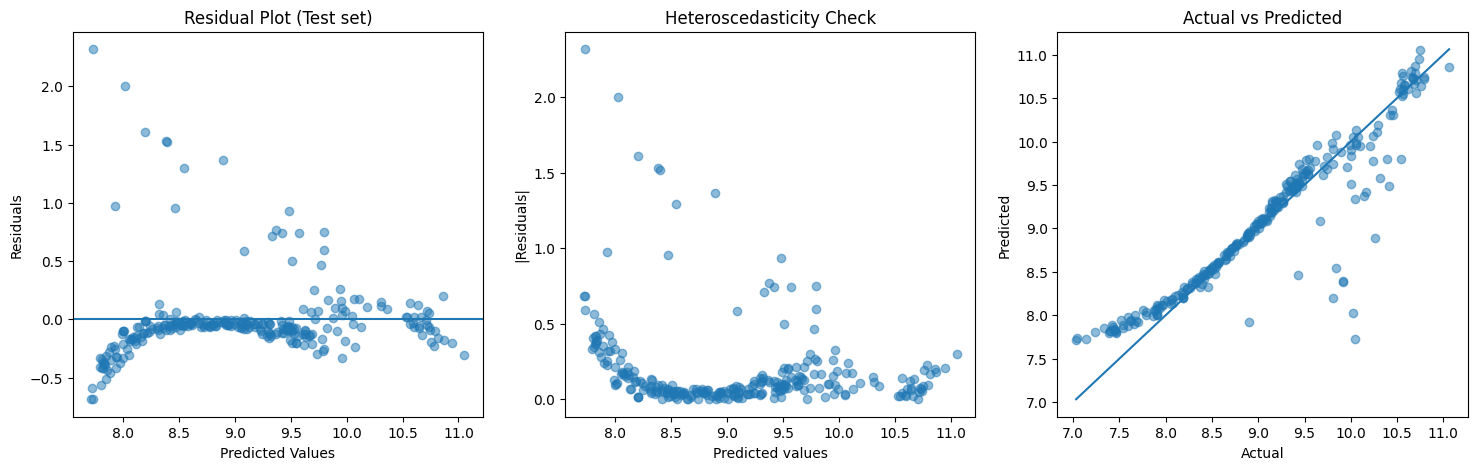

In [85]:
evaluate_model(pipe_ols, X_train, X_test, y_train, y_test, log = True)
graph_residuals(pipe_ols, X_test, y_test)

### 5.3. LASSO

In [86]:
### Initialize pipeline
pipe_lasso = Pipeline([
    ('model', LassoCV(cv = 5, n_jobs = -1, random_state = random_state))
])

### Fit model on training data
pipe_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001


In [ ]:
### Print Lasso alpha hypermeter value
print(f'Lasso alpha: {pipe_lasso.named_steps["model"].alpha_:.4f}')
print('-'*40)

### Lasso coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe_lasso.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### Lasso intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_lasso.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
print(full_df)


Lasso alpha: 0.0096
----------------------------------------
             feature      coef
0          intercept  7.077647
1       smoker x bmi  0.753136
2       obese_smoker  0.276593
3           children  0.094653
4                sex  0.041225
5                age  0.040744
6   region_southwest -0.037240
7       smoker x age -0.030567
8   region_southeast -0.004076
9                bmi  0.000000
10  region_northwest  0.000000
11            smoker  0.000000



LassoCV
----------------------------------------
Train:
CV RMSE: 4931.2603
RMSE: 4938.90
MAE:  2483.73
R²:   0.8310

Test:
RMSE: 4481.53
MAE:  2194.67
R²:   0.8706


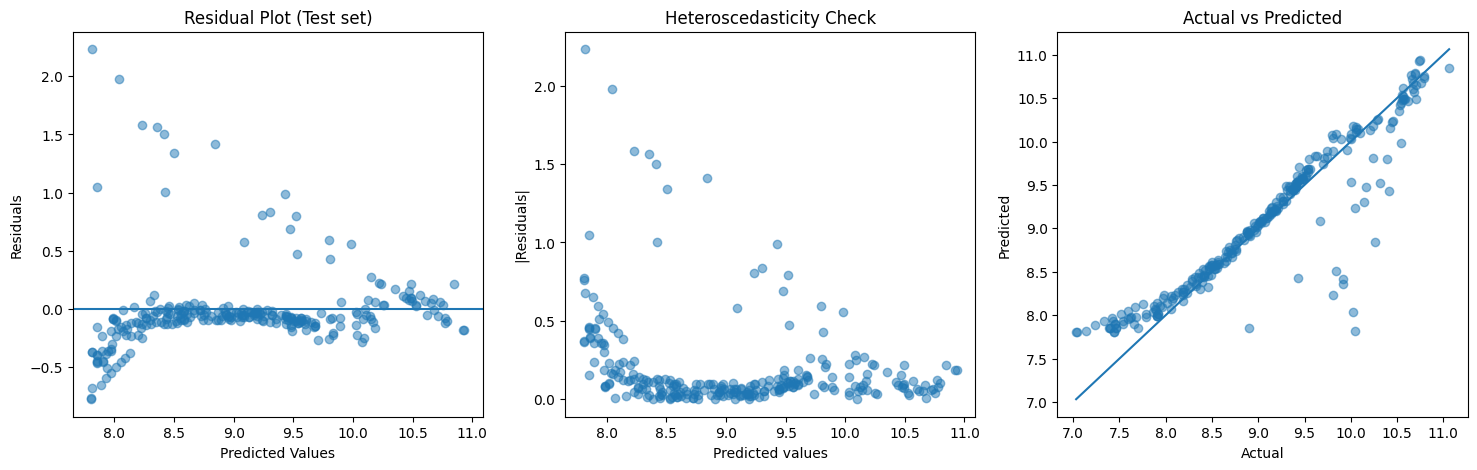

In [96]:
evaluate_model(pipe_lasso, X_train, X_test, y_train, y_test, log = True)
graph_residuals(pipe_lasso, X_test, y_test)

### 5.4. Post-Lasso OLS

In [97]:
### Initialize pipeline
pipe_post_lasso = Pipeline([
    ('model', LinearRegression())
])

### Select features that were not shrunk to zero by Lasso   
selected_features = X_train.columns[pipe_lasso.named_steps["model"].coef_ != 0]

### Print to verify
print(selected_features)

### Modify training and test sets to include only selected features
X_train_post_lasso = X_train[selected_features] 
X_test_post_lasso = X_test[selected_features]

### Fit model on training data
pipe_post_lasso.fit(X_train_post_lasso, y_train)

Index(['age', 'sex', 'children', 'region_southeast', 'region_southwest',
       'smoker x bmi', 'smoker x age', 'obese_smoker'],
      dtype='object')


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



Post-Lasso OLS
----------------------------------------
Train:
CV RMSE: 4947.6913
RMSE: 4951.50
MAE:  2457.49
R²:   0.8301

Test:
RMSE: 4656.32
MAE:  2245.05
R²:   0.8603


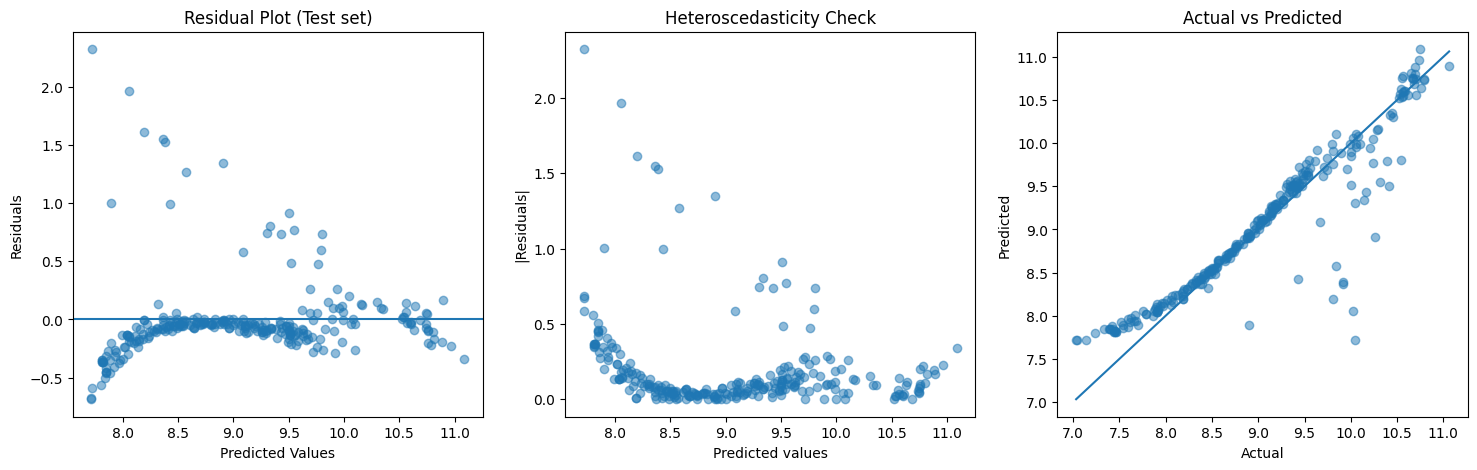

In [98]:
evaluate_model(pipe_post_lasso, X_train_post_lasso, X_test_post_lasso, y_train, y_test, log = True, name = 'Post-Lasso OLS')
graph_residuals(pipe_post_lasso, X_test_post_lasso, y_test)

### 5.5. Ridge

In [99]:
### Initialize pipeline
pipe_ridge = Pipeline([
    ('model', RidgeCV(cv=5, alphas=np.logspace(-3, 3, 100), scoring='neg_mean_squared_error'))
])

### Fit model on training data
pipe_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is spar

In [ ]:
### Print Ridge alpha hypermeter value
print(f'Ridge alpha: {pipe_ridge.named_steps["model"].alpha_:.4f}')
print('-'*40)

### Ridge coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe_ridge.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### Ridge intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_ridge.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
print(full_df)

Ridge alpha: 2.4771
----------------------------------------
             feature      coef
0          intercept  6.954257
1       smoker x bmi  0.700505
2       obese_smoker  0.463175
3             smoker  0.199508
4   region_southwest -0.153421
5   region_southeast -0.119841
6           children  0.101889
7                sex  0.085289
8   region_northwest -0.057849
9                bmi  0.042805
10               age  0.041209
11      smoker x age -0.033278



RidgeCV
----------------------------------------
Train:
CV RMSE: 4950.7805
RMSE: 4947.87
MAE:  2462.69
R²:   0.8304

Test:
RMSE: 4598.16
MAE:  2226.70
R²:   0.8638


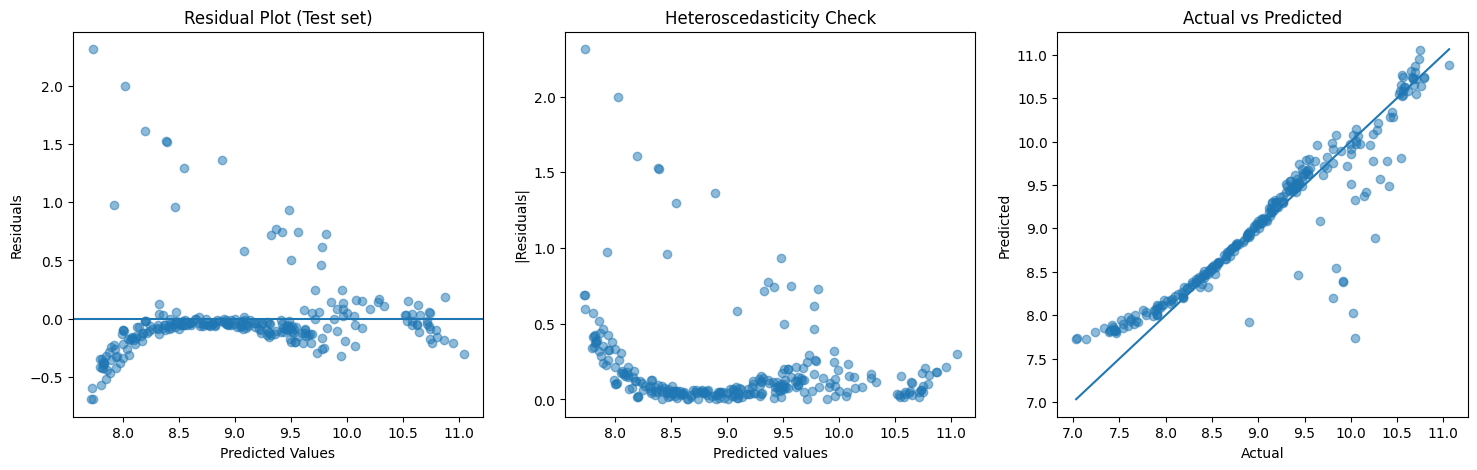

In [101]:
evaluate_model(pipe_ridge, X_train, X_test, y_train, y_test, log = True)
graph_residuals(pipe_ridge, X_test, y_test)

### 5.6. Polynomial 

In [103]:
### Initialize Pipeline
pipe_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

### Fit model on training data
pipe_poly.fit(X_train_raw, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [107]:
### Polynomial features
poly_features = pipe_poly.named_steps["poly"].get_feature_names_out(X_train_raw.columns)


### Polynomial coefficients
coef_df = pd.DataFrame({
    "feature": poly_features,
    "value": pipe_poly.named_steps["model"].coef_
})

### Polynomial intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "value": [pipe_poly.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
print(full_df)

                              feature     value
0                           intercept  5.768649
1                                 age  0.060131
2                                 sex  0.227602
3                                 bmi  0.050422
4                            children  0.360998
5                              smoker  0.685722
6                    region_northwest  0.073810
7                    region_southeast -0.029406
8                    region_southwest -0.118913
9                               age^2 -0.000184
10                            age sex -0.004753
11                            age bmi -0.000119
12                       age children -0.004321
13                         age smoker -0.032556
14               age region_northwest  0.003071
15               age region_southeast  0.007708
16               age region_southwest  0.009237
17                              sex^2  0.227602
18                            sex bmi -0.003739
19                       sex children -0


Polynomial Regression
----------------------------------------
Train:
CV RMSE: 5251.6791
RMSE: 5158.25
MAE:  2689.22
R²:   0.8157

Test:
RMSE: 4749.14
MAE:  2404.55
R²:   0.8547


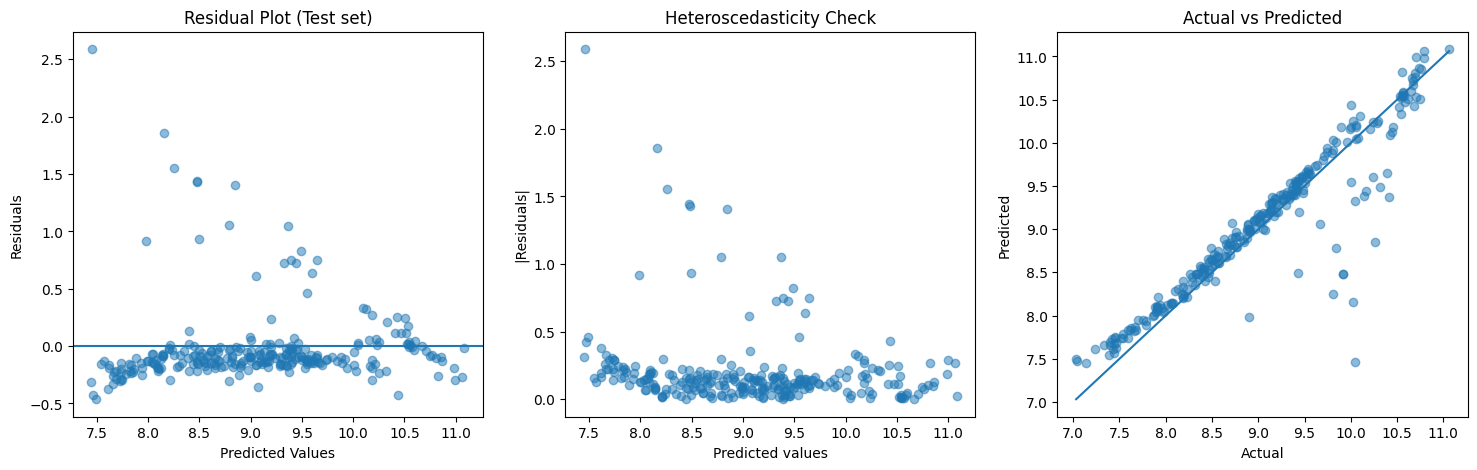

In [105]:
evaluate_model(pipe_poly, X_train_raw, X_test_raw, y_train, y_test, log = True, name = 'Polynomial Regression')
graph_residuals(pipe_poly, X_test_raw, y_test)

### 5.7. Random Forest

In [ ]:
### Initialize Pipeline
pipe_rf = Pipeline([
    ('model', RandomForestRegressor(n_estimators=100, random_state=random_state))])

## 6. Final Evaluation